In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

df = pd.read_csv("../dataset/vietnam_real_estate_fnl.csv")

In [38]:
# tiền xử lý
numeric_cols = [
    "price",
    "area",
    "floor_count",
    "frontage_width",
    "bedroom_count",
    "bathroom_count"
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Loại các giá trị không hợp lệ
df = df[
    (df["price"] > 0) &
    (df["area"] > 0)
].copy()

# Thêm cột giá trên mỗi mét vuông
df["price_per_m2"] = df["price"] / df["area"]
display(df[numeric_cols + ["price_per_m2"]].describe())

,price,area,floor_count,frontage_width,bedroom_count,bathroom_count,price_per_m2
count,9.227000e+03,9227.000000,2257.000000,4862.000000,5011.000000,4681.000000,9.227000e+03
mean,1.407673e+10,212.315511,3.932654,7.554803,3.423867,3.186712,1.347099e+08
std,2.921538e+10,1569.353830,1.640544,10.267954,2.755278,2.880335,1.317813e+08
min,7.500000e+06,3.400000,1.000000,2.000000,1.000000,1.000000,4.761905e+04
25%,4.100000e+09,55.000000,3.000000,4.200000,2.000000,2.000000,5.150452e+07
50%,7.400000e+09,79.000000,4.000000,5.000000,3.000000,2.000000,9.722222e+07
75%,1.388900e+10,120.000000,5.000000,7.400000,4.000000,4.000000,1.861034e+08
max,1.137000e+12,78813.400000,11.000000,300.000000,56.000000,66.000000,4.676471e+09


##### Sau bước tiền xử lý (ép kiểu numeric, loại price/area ≤ 0), dataset còn 9,227 bất động sản với các đặc trưng: giá, diện tích, số tầng, mặt tiền, số phòng ngủ/tắm, tỉnh thành, loại hình BĐS.

**Điểm đáng chú ý: phân phối giá và diện tích cực kỳ lệch phải:**

1. price: trung vị ~7.4 tỷ, nhưng max lên tới 1,137 tỷ (~1.14 nghìn tỷ)
2. area: trung vị 79m2, nhưng max 78,813 m2 — gần như chắc chắn là outlier/lỗi nhập liệu, có thể là đất dự án lớn bị gộp nhầm đơn vị.

### 1. Diện tích ảnh hưởng thế nào đến giá nhà?

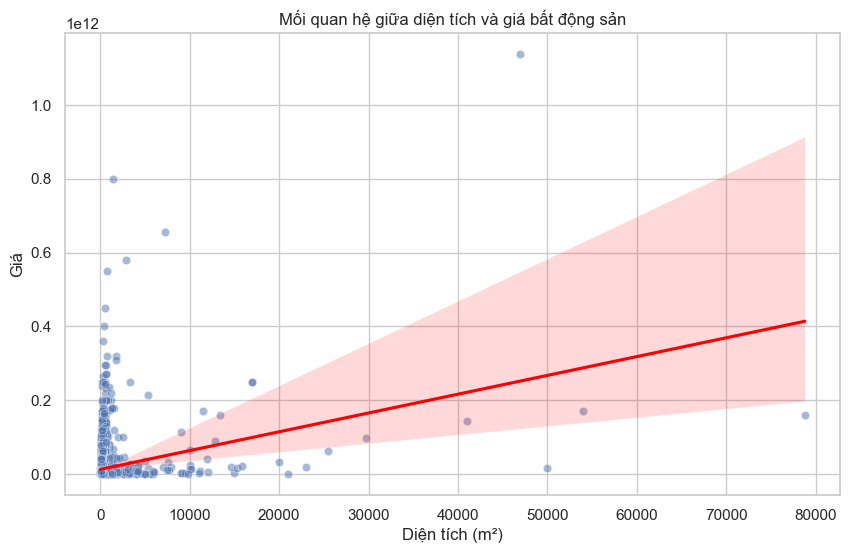

In [ ]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="area",
    y="price",
    alpha=0.5
)

sns.regplot(
    data=df,
    x="area",
    y="price",
    scatter=False,
    color="red"
)

plt.title("Mối quan hệ giữa diện tích và giá bất động sản")
plt.xlabel("Diện tích (m2)")
plt.ylabel("Giá")
plt.show()

### 2. Giá trên mỗi m2 thay đổi thế nào theo diện tích?

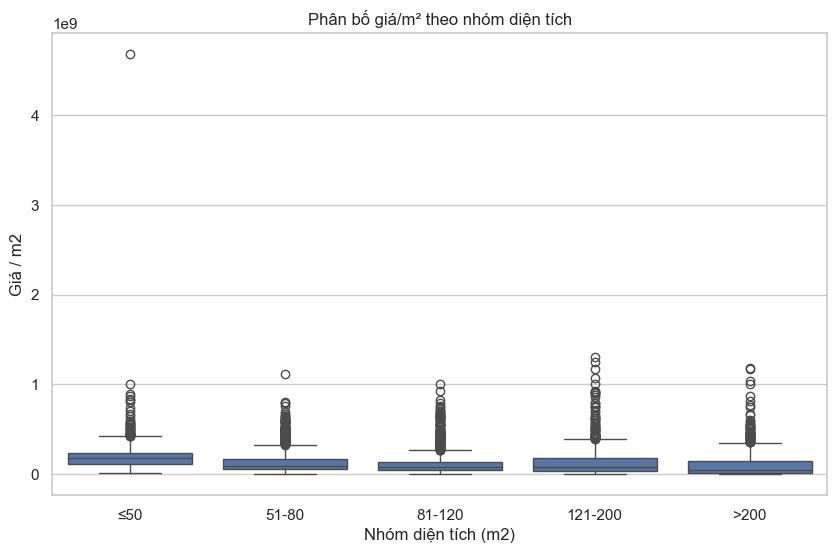

In [ ]:
df["area_group"] = pd.cut(
    df["area"],
    bins=[0, 50, 80, 120, 200, np.inf],
    labels=["≤50", "51-80", "81-120", "121-200", ">200"]
)

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="area_group",
    y="price_per_m2"
)

plt.title("Phân bố giá/m2 theo nhóm diện tích")
plt.xlabel("Nhóm diện tích (m2)")
plt.ylabel("Giá / m2")
plt.show()

### 3. Vị trí tỉnh thành ảnh hưởng thế nào đến giá?

In [37]:
province_stats = (
    df.groupby("province_name")
      .agg(
          median_price=("price", "median"),
          median_price_per_m2=("price_per_m2", "median"),
          count=("price", "count")
      )
      .sort_values("median_price_per_m2", ascending=False)
)


In [36]:
province_counts = df["province_name"].value_counts()

valid_provinces = province_counts[
    province_counts >= 30
].index

df_province = df[
    df["province_name"].isin(valid_provinces)
].copy() #lấy các tỉnh thành có trên 30 BDS

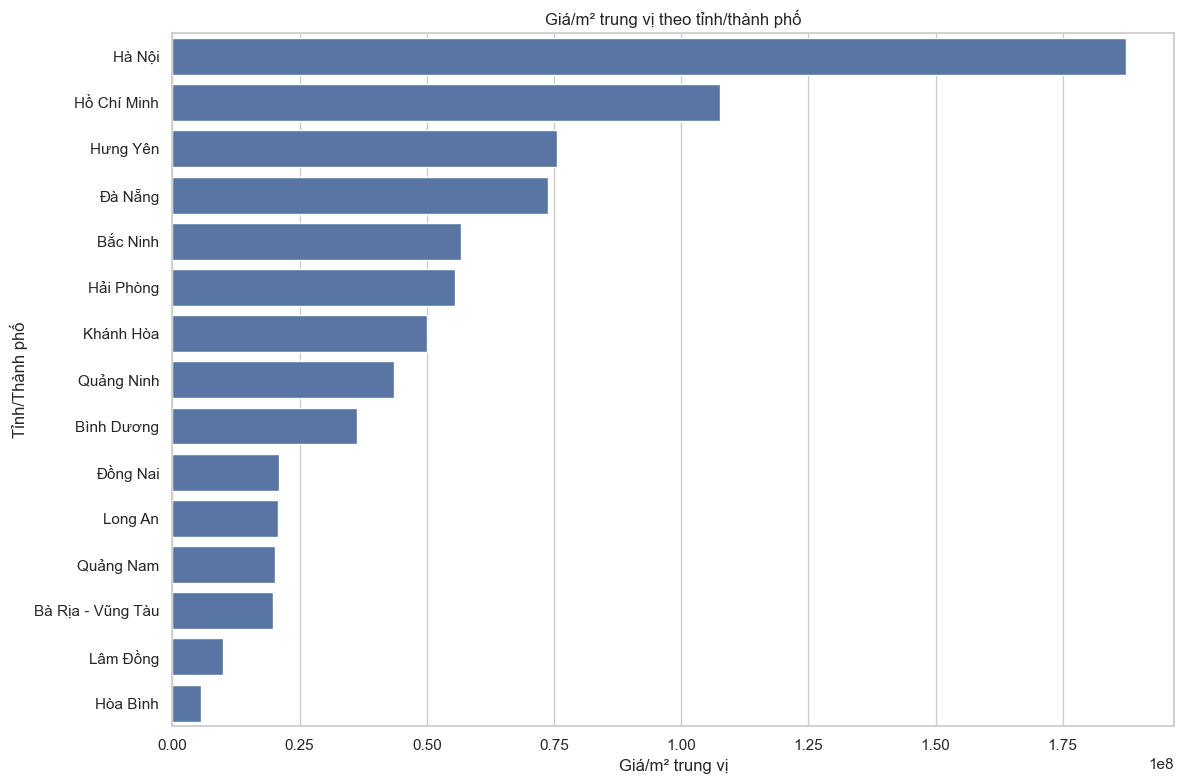

In [ ]:
province_median = (
    df_province.groupby("province_name")["price_per_m2"]
    .median()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(12, 8))

sns.barplot(
    data=province_median,
    x="price_per_m2",
    y="province_name"
)

plt.title("Giá/m2 trung vị theo tỉnh/thành phố")
plt.xlabel("Giá/m2 trung vị")
plt.ylabel("Tỉnh/Thành phố")

plt.tight_layout()
plt.show()

### 4. Giá khác nhau thế nào giữa các loại nhà?

In [19]:
house_type_stats = (
    df.groupby("property_type_name")
      .agg(
          median_price=("price", "median"),
          median_price_per_m2=("price_per_m2", "median"),
          count=("price", "count")
      )
      .sort_values("median_price", ascending=False)
)

display(house_type_stats)

,median_price,median_price_per_m2,count
property_type_name,,,
Biệt thự/Nhà liền kề,1.890000e+10,1.542857e+08,685
Nhà,8.900000e+09,1.666667e+08,4318
Shophouse,8.900000e+09,8.928571e+07,149
Căn hộ chung cư,4.850000e+09,6.758333e+07,1891
Đất,4.500000e+09,3.644615e+07,2184


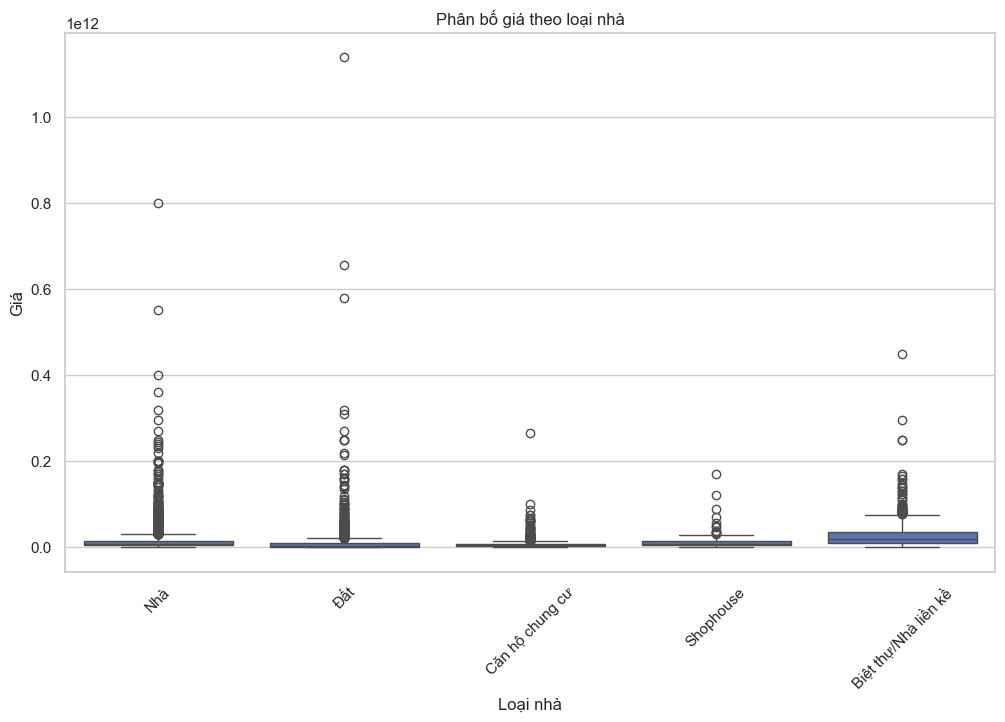

In [21]:
plt.figure(figsize=(12, 7))

sns.boxplot(
    data=df,
    x="property_type_name",
    y="price"
)

plt.title("Phân bố giá theo loại nhà")
plt.xlabel("Loại nhà")
plt.ylabel("Giá")

plt.xticks(rotation=45)
plt.show()

### 5. Số phòng ngủ ảnh hưởng thế nào đến giá?

### 6. Số phòng tắm ảnh hưởng thế nào đến giá?

### 7. Số tầng ảnh hưởng thế nào đến giá?

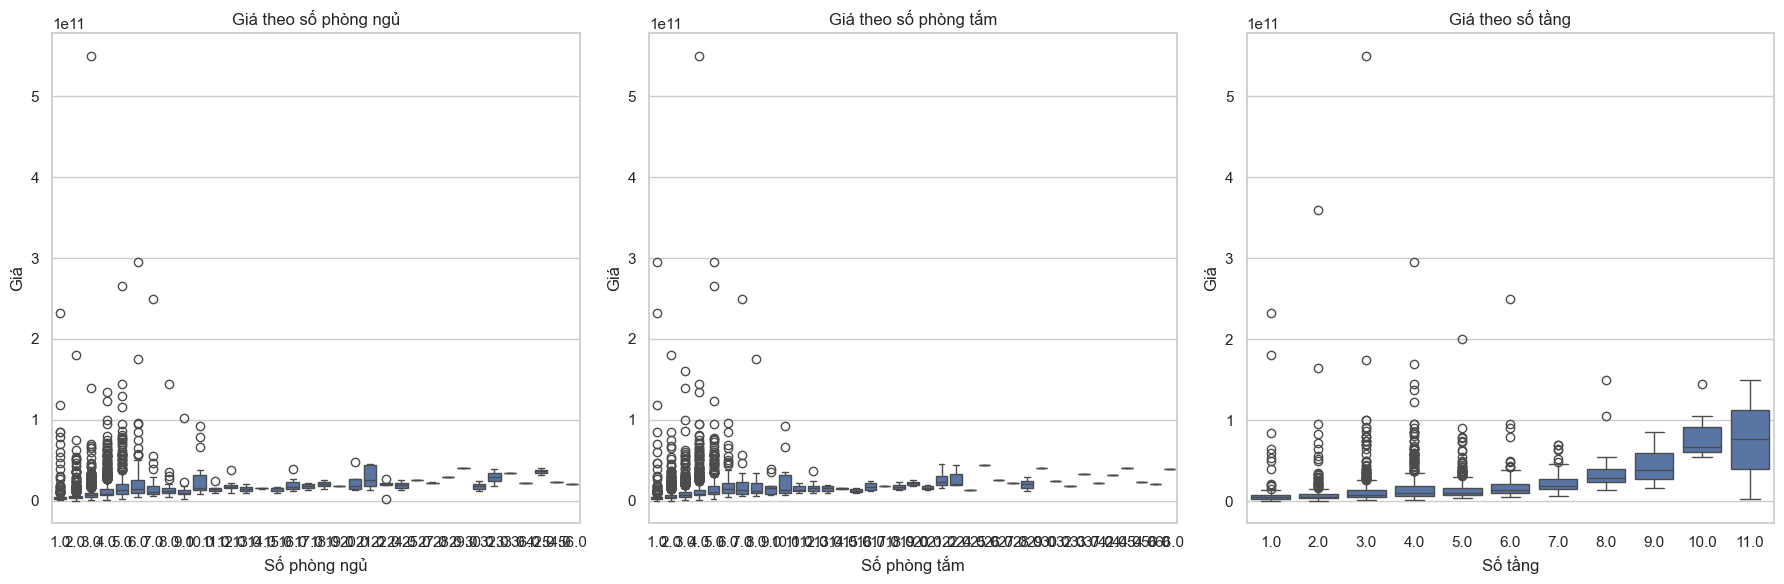

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

features = [
    ("bedroom_count", "Số phòng ngủ"),
    ("bathroom_count", "Số phòng tắm"),
    ("floor_count", "Số tầng")
]

for ax, (col, title) in zip(axes, features):
    sns.boxplot(
        data=df,
        x=col,
        y="price",
        ax=ax
    )

    ax.set_title(f"Giá theo {title.lower()}")
    ax.set_xlabel(title)
    ax.set_ylabel("Giá")

plt.tight_layout()
plt.show()

### 8. Chiều rộng mặt tiền ảnh hưởng thế nào đến giá?

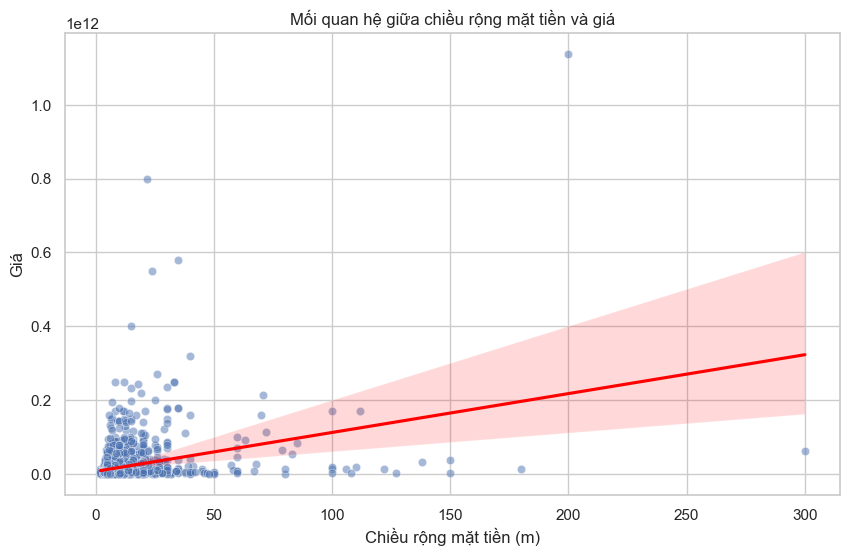

In [25]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="frontage_width",
    y="price",
    alpha=0.5
)

sns.regplot(
    data=df,
    x="frontage_width",
    y="price",
    scatter=False,
    color="red"
)

plt.title("Mối quan hệ giữa chiều rộng mặt tiền và giá")
plt.xlabel("Chiều rộng mặt tiền (m)")
plt.ylabel("Giá")
plt.show()

    
EDA 1 - 2. Diện tích vs Giá: Có tương quan dương nhưng yếu và bị outlier chi phối mạnh (vài điểm diện tích siêu lớn kéo đường hồi quy lệch, dải tin cậy rất rộng ở vùng diện tích lớn do quá ít dữ liệu). Giá/m2 lại có xu hướng giảm nhẹ khi diện tích tăng (nhóm <= 50m2 có giá/m2 trung vị cao nhất) — hợp lý vì nhà nhỏ ở khu trung tâm thường đắt hơn tính trên từng m2.

EDA 3. Theo tỉnh/thành: Hà Nội dẫn đầu giá/m2 trung vị (khoảng 188 triệu/m2), theo sau là TP.HCM (khoảng 108 triệu/m2), rồi Hưng Yên, Đà Nẵng, Bắc Ninh... Chênh lệch giữa Hà Nội và tỉnh thấp nhất (Hòa Bình) lên tới hơn 30 lần.

EDA 4. Theo loại hình: Biệt thự/Nhà liền kề có giá trung vị cao nhất (khoảng 18.9 tỷ) và giá/m2 cao; Đất có giá tổng thấp nhất nhưng biến động lớn
(outlier 1,137 tỷ nằm ở nhóm này). Căn hộ chung cư có giá/m2 thấp nhất, phân bố chặt nhất (ít outlier) — hợp lý vì căn hộ đồng nhất hơn nhà đất.

EDA 5 - 7. Phòng ngủ/tắm/số tầng: Boxplot bị outlier áp đảo khiến khó đọc xu hướng — trục x có quá nhiều mức rời rạc (1 đến 56 phòng ngủ!) khiến biểu đồ rối. Số tầng cho thấy xu hướng hợp lý hơn: nhà càng nhiều tầng, giá trung vị càng tăng đều đặn.

EDA 8. Mặt tiền vs Giá: Tương quan dương nhẹ, tương tự pattern của diện tích, cũng bị outlier chi phối (mặt tiền max 300m là bất thường).